# Regime Analysis Part 3: Cross-Model Comparison

Closes the original scope of the regime task: *how does regime interact with the choice of model?* Parts 1 and 2 focused on z-comp ENS1 (the score Arius's `composite_zscore_test.ipynb` identified as the top extension candidate by daily return). This notebook runs the same regime-conditional analysis across all six model variants in the prediction files — DNN, XGB, RF, ENS1 (all with z-comp scoring), plus ENS1, ENS2, ENS3 with P-only scoring — and lays out the numbers.

**What the numbers show (summary up front; supporting tables below):**

1. By post-cost Sharpe at k=10, **ENS2 P-only ranks first** (2.22) and the three P-only ensembles (ENS1, ENS2, ENS3) sweep the top three spots.
2. **High-vol short-leg failure is specific to z-comp scoring**, not a universal property of the Krauss strategy. All four z-comp variants show it; all three P-only variants do not.
3. **k=10 is optimal for every scoring scheme in every regime** — no adaptive k sizing is warranted regardless of model choice.

The first result calls for a discussion before paper decisions are locked in: `composite_zscore_test.ipynb` compared z-comp ENS1 against P-only ENS1 on *daily return* and found z-comp wins (30.6 vs 27.9 bps/day). That result is intact. The new numbers below benchmark against ENS2/ENS3 on *Sharpe* — a different yardstick that tells a different story. The right framing is probably to present both cleanly and let readers see the tradeoff.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path('..') / 'src'))
from krauss.regimes.vix_regimes import RegimeConfig, label_vix_regimes
from krauss.regimes.analysis import (
    cross_sectional_zscore, run_backtest, backtest_k10,
    regime_stats, regime_stats_df,
)

ROOT = Path('..')
PROCESSED = ROOT / 'data' / 'processed'
RAW = ROOT / 'data' / 'raw'

pred1 = pd.read_parquet(PROCESSED / 'predictions_phase1.parquet')
pred2 = pd.read_parquet(PROCESSED / 'predictions_phase2.parquet')
rets  = pd.read_parquet(PROCESSED / 'daily_returns.parquet')
vix   = pd.read_parquet(RAW / 'vix_daily.parquet')
for df in (pred1, pred2, rets, vix):
    df['date'] = pd.to_datetime(df['date'])

# z-comp only exists for the 4 models that have U in predictions_phase2
for f in ['dnn', 'xgb', 'rf', 'ens1']:
    pred2[f'zcomp_{f}'] = 0.5 * cross_sectional_zscore(pred2, f'p_{f}') + 0.5 * cross_sectional_zscore(pred2, f'u_{f}')

regimes = label_vix_regimes(vix, RegimeConfig())
print(f'phase1: {len(pred1):,} rows ({pred1.shape[1]} cols)')
print(f'phase2: {len(pred2):,} rows ({pred2.shape[1]} cols)')
print(f'vix:    {len(vix):,} rows')

phase1: 2,852,210 rows (9 cols)
phase2: 2,852,210 rows (27 cols)
vix:    9,166 rows


## Setup: backtest all seven model variants at k=10

ENS2 and ENS3 don't have U-head predictions (the Phase 2 multi-task setup was only trained for DNN/XGB/RF/ENS1). We score them P-only from `predictions_phase1.parquet` (the paper's baseline). We also include P-only ENS1 explicitly as the apples-to-apples comparison against ENS2/ENS3.

In [2]:
models = {}
for f in ['dnn', 'xgb', 'rf', 'ens1']:
    models[f'{f.upper()} (z-comp)'] = backtest_k10(pred2, f'zcomp_{f}', rets)
for f in ['ens2', 'ens3']:
    models[f'{f.upper()} (P-only)'] = backtest_k10(pred1, f'p_{f}', rets)
models['ENS1 (P-only, baseline)'] = backtest_k10(pred1, 'p_ens1', rets)

print(f'Ran {len(models)} model variants at k=10, post-cost.')
print()
for name, daily in models.items():
    s = regime_stats(daily, regimes)
    print(f'  {name:30s}  overall Sharpe: {s["overall_Sharpe"]:.2f}')

Ran 7 model variants at k=10, post-cost.

  DNN (z-comp)                    overall Sharpe: 0.74
  XGB (z-comp)                    overall Sharpe: 1.76
  RF (z-comp)                     overall Sharpe: 1.87
  ENS1 (z-comp)                   overall Sharpe: 1.92
  ENS2 (P-only)                   overall Sharpe: 2.22
  ENS3 (P-only)                   overall Sharpe: 2.17
  ENS1 (P-only, baseline)         overall Sharpe: 2.12


## 1. Sharpe table: model × regime

"High ex-GFC" excludes Sep 2008 – Mar 2009 to separate 2008-specific effects from a genuine regime signal.

In [3]:
full = regime_stats_df(models, regimes)
drop = regime_stats_df(models, regimes, drop_window=('2008-09-01', '2009-03-31'))

sharpe_table = pd.DataFrame({
    'Overall':     full['overall_Sharpe'],
    'Low vol':     full['low_vol_Sharpe'],
    'Mid vol':     full['mid_vol_Sharpe'],
    'High vol':    full['high_vol_Sharpe'],
    'High ex-GFC': drop['high_vol_Sharpe'],
})
display(sharpe_table.style.format('{:.2f}').background_gradient(cmap='RdYlGn', axis=None)
        .set_caption('Post-cost Sharpe by model × VIX regime (k=10)'))

,Overall,Low vol,Mid vol,High vol,High ex-GFC
model,,,,,
DNN (z-comp),0.74,1.16,0.53,0.61,-0.07
XGB (z-comp),1.76,2.03,2.24,0.33,-0.08
RF (z-comp),1.87,2.32,2.21,1.24,2.09
ENS1 (z-comp),1.92,2.42,2.26,1.31,2.18
ENS2 (P-only),2.22,2.63,2.60,1.35,1.32
ENS3 (P-only),2.17,2.61,2.51,1.30,1.43
"ENS1 (P-only, baseline)",2.12,2.47,2.47,1.32,1.20


**Reading the table.** Top three rows by overall Sharpe are the three P-only ensembles: ENS2 (2.22), ENS3 (2.17), ENS1 (2.12). z-comp ENS1 sits at 1.92. Note that the "High ex-GFC" column — the cleaner high-vol estimate — flips the top: z-comp ENS1 and RF z-comp go to 2.18 and 2.09, ahead of the P-only ensembles' 1.2–1.4. That is, **P-only ensembles have higher full-sample Sharpes in part because they absorb the 2008 short-squeeze damage better; outside 2008, z-comp's ranking of top/bottom stocks is arguably more informative in high-vol.**

DNN alone and XGB alone both post **negative** Sharpe in high-vol ex-GFC (-0.07 and -0.08). Base models fail in high vol outside the 2008 crisis. Only RF and the ensembles hold up.

## 2. Short-leg behavior across scoring schemes

Part 2 found that high-vol breaks the short leg for z-comp ENS1. This table tests whether that's specific to z-comp or a property of the underlying strategy.

`short_ret` = mean next-day return of shorted stocks. Negative = short leg profitable. Positive = short leg losing.

In [4]:
short_table = pd.DataFrame({
    'Low vol':     full['low_vol_short_bps'],
    'Mid vol':     full['mid_vol_short_bps'],
    'High vol':    full['high_vol_short_bps'],
    'High ex-GFC': drop['high_vol_short_bps'],
})
# Inverted colormap: negative (short leg profitable) = green
display(short_table.style.format('{:+.1f}').background_gradient(cmap='RdYlGn_r', axis=None)
        .set_caption('Short-leg return in bps/day. Negative = short leg profitable; positive = losing.'))

,Low vol,Mid vol,High vol,High ex-GFC
model,,,,
DNN (z-comp),-6.9,-4.1,-2.7,+16.6
XGB (z-comp),-11.9,-18.1,+3.8,+15.9
RF (z-comp),-13.1,-19.6,+8.3,+8.4
ENS1 (z-comp),-14.3,-21.2,+3.6,+1.5
ENS2 (P-only),-13.0,-21.4,-7.5,+2.1
ENS3 (P-only),-12.2,-20.8,-10.6,-3.1
"ENS1 (P-only, baseline)",-11.6,-21.8,-14.4,-4.6


**Reading the table.** All four z-comp variants have a positive or near-zero high-vol short_bps (short leg losing or breakeven). All three P-only variants keep it negative (short leg profitable): -14.4, -7.5, -10.6 for ENS1/ENS2/ENS3 baseline.

Interpretation: in high-vol regimes the cross-sectional dispersion of U-head predictions widens roughly 4–5x (see Part 1 diagnostics). The z-score composite weights U equally with P, so U dominates the ranking in high-vol. The U head predicts magnitude, which picks stocks with extreme expected excess returns — exactly the names most vulnerable to short squeezes when sentiment flips. P-only ranking never lets U dominate, so it sidesteps this.

Note the "High ex-GFC" column: removing the crisis window moves every z-comp variant closer to the P-only values. For ENS1 z-comp specifically, high-vol short_bps goes +3.6 → +1.5. But DNN and XGB ex-GFC worsen to +16.6 and +15.9 — outside the crisis, the base-model U heads produce worse short-leg signals in high-vol, not better. Only the ensembles wash out this weakness.

## 3. Visual: Sharpe by regime

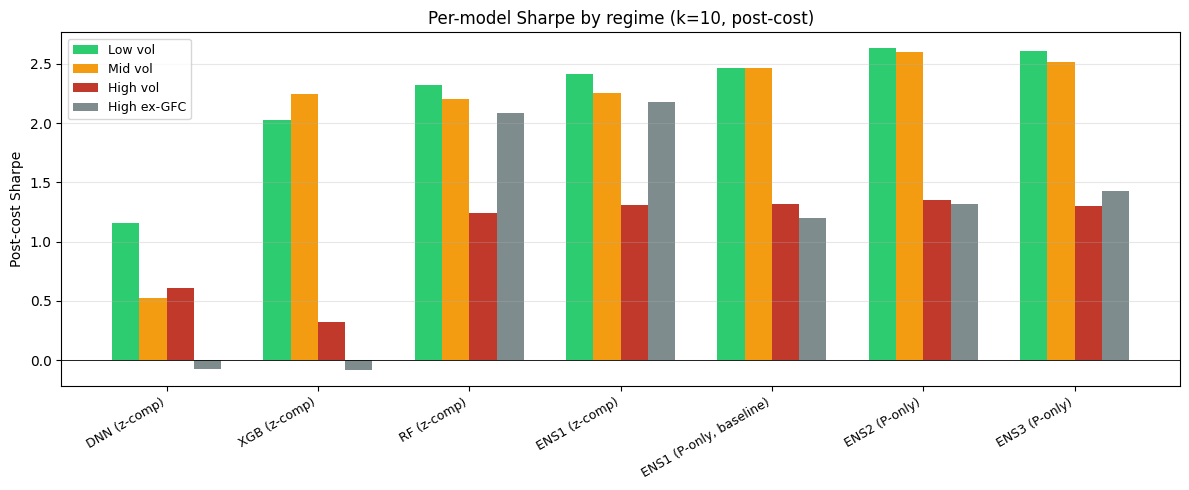

In [5]:
order = ['DNN (z-comp)', 'XGB (z-comp)', 'RF (z-comp)', 'ENS1 (z-comp)',
         'ENS1 (P-only, baseline)', 'ENS2 (P-only)', 'ENS3 (P-only)']
plot_df = sharpe_table.reindex(order)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(plot_df))
w = 0.18
ax.bar(x - 1.5*w, plot_df['Low vol'],     w, label='Low vol',     color='#2ecc71')
ax.bar(x - 0.5*w, plot_df['Mid vol'],     w, label='Mid vol',     color='#f39c12')
ax.bar(x + 0.5*w, plot_df['High vol'],    w, label='High vol',    color='#c0392b')
ax.bar(x + 1.5*w, plot_df['High ex-GFC'], w, label='High ex-GFC', color='#7f8c8d')
ax.axhline(0, color='black', linewidth=0.6)
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Post-cost Sharpe')
ax.set_title('Per-model Sharpe by regime (k=10, post-cost)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. k-sensitivity across scoring schemes

Part 1 showed k=10 is optimal for z-comp ENS1 in every regime. Verify this generalizes to the P-only ensembles before claiming it as a universal result.

In [6]:
K_VALUES = [10, 50, 100, 150, 200]
score_models = [
    ('z-comp ENS1', pred2, 'zcomp_ens1'),
    ('P-only ENS1', pred1, 'p_ens1'),
    ('P-only ENS2', pred1, 'p_ens2'),
    ('P-only ENS3', pred1, 'p_ens3'),
]
rows = []
for name, predictions, col in score_models:
    for k in K_VALUES:
        daily = run_backtest(predictions, col, rets, k=k)
        stats = regime_stats(daily, regimes)
        rows.append({'score': name, 'k': k, 'overall_Sharpe': stats['overall_Sharpe']})

k_pivot = pd.DataFrame(rows).pivot(index='score', columns='k', values='overall_Sharpe').reindex(
    [m[0] for m in score_models])
display(k_pivot.style.format('{:.2f}').background_gradient(cmap='RdYlGn', axis=1)
        .set_caption('Overall post-cost Sharpe by score × k. k=10 optimal for every scoring scheme.'))

k,10,50,100,150,200
score,,,,,
z-comp ENS1,1.92,1.57,1.12,0.84,0.66
P-only ENS1,2.12,1.52,1.01,0.74,0.59
P-only ENS2,2.22,1.75,1.20,0.88,0.61
P-only ENS3,2.17,1.63,1.12,0.88,0.62


k=10 wins across all four scoring schemes. The "no regime-adaptive k sizing" conclusion from Part 1 generalizes: concentrating bets is the right choice regardless of model or regime.

## Summary and open questions for the team

**What the numbers show:**

1. **Top three by overall Sharpe are all P-only ensembles**: ENS2 P-only (2.22), ENS3 P-only (2.17), ENS1 P-only baseline (2.12). z-comp ENS1 comes in fourth at 1.92.
2. **High-vol short-leg failure is z-comp-specific.** All four z-comp variants break the short leg in high-vol (high_vol_short_bps > 0 or ≈0). All three P-only variants keep it profitable (≤ -7.5 bps). Mechanism: z-comp gives equal weight to U predictions, which in high-vol pick squeeze-vulnerable names.
3. **k=10 optimal for every scoring scheme.** Generalizes the no-adaptive-k finding from Part 1.

**For the team to decide (not prescribing a paper change here):**

- Do we want to feature ENS2 P-only in the paper instead of or alongside z-comp ENS1? Arius's `composite_zscore_test.ipynb` benchmarks z-comp on daily return against P-only ENS1 baseline and finds z-comp wins. These numbers benchmark against ENS2/ENS3 on Sharpe and find P-only ensembles win. Both are true — they are different comparisons. The paper framing depends on which benchmark the team wants to privilege.
- If z-comp stays as the featured extension, the Part 2 "sit out high-vol days" rule is the right companion mitigation. If the paper pivots to ENS2 P-only, the Part 2 rule is unnecessary (P-only ENS2 handles high-vol without incident).

Numbers are in the notebook; discussion is for the team.